# Sarmaşık verisine ilk bakış

Veri: *When Plants Respond* (Buss vd., 2025), Zenodo 15095523. 4 sarmaşık bitkisi (P1, P2, P3, P5), dış ortam, Temmuz–Kasım 2024. Her bitkide 2 kanal (CH1, CH2), saniyede 1 ölçüm.

Hücreleri sırayla çalıştırmak için: **Shift + Enter**.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from bitki_ekg.data import SARMASIK_BITKILER, sarmasik_bitki, sarmasik_dosyalari, sarmasik_hava
from bitki_ekg.config import get_path

plt.rcParams['figure.dpi'] = 110
SEKIL = get_path('figures')

## 1. Tek bir dosya: 12 saatlik ham sinyal (1 Hz)

In [2]:
f = sarmasik_dosyalari('P1')[10]
ham = pd.read_csv(f, parse_dates=['datetime'], index_col='datetime').dropna(how='all')
print(f.name, ham.shape)
ham.head()

P1_2024-07-27_00-00-00.csv (43201, 2)


,CH1,CH2
datetime,,
2024-07-26 23:59:59,8.147005e+06,8.125959e+06
2024-07-27 00:00:00,8.147076e+06,8.126171e+06
2024-07-27 00:00:01,8.147494e+06,8.126221e+06
2024-07-27 00:00:02,8.148000e+06,8.126156e+06
2024-07-27 00:00:03,8.148537e+06,8.126055e+06


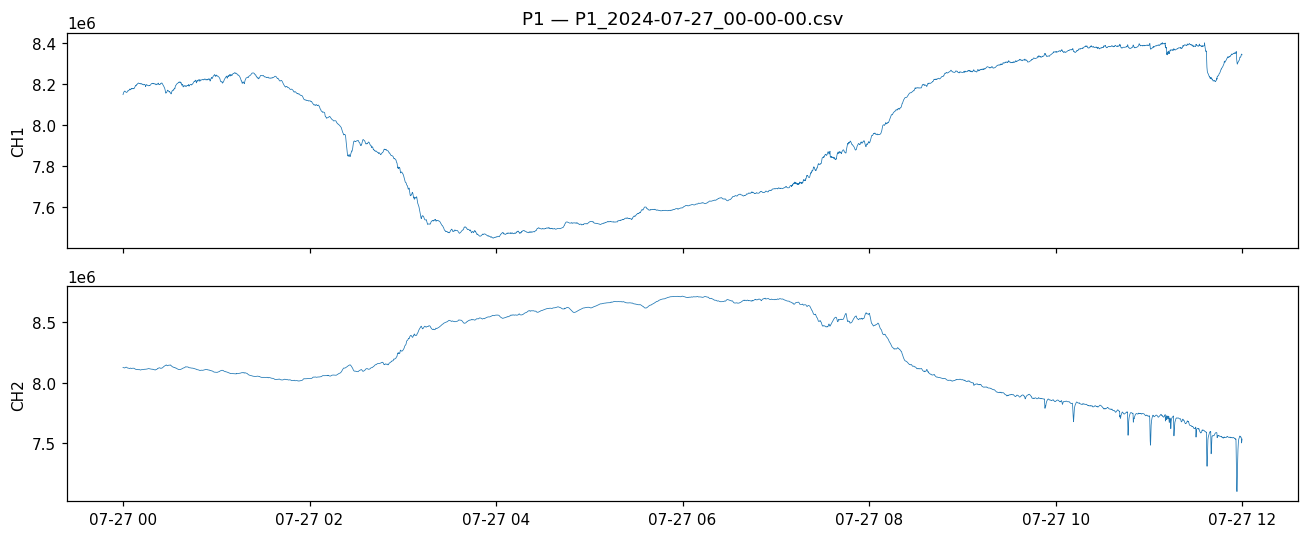

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for a, ch in zip(ax, ['CH1', 'CH2']):
    a.plot(ham.index, ham[ch], lw=0.5)
    a.set_ylabel(ch)
ax[0].set_title(f'P1 — {f.name}')
plt.tight_layout(); plt.show()

## 2. Tüm bitkiler, tüm kayıt (1 dakikalık ortalama)

Tüm kayıt 1 Hz'de milyonlarca satır; görselleştirme için 1 dakikaya seyreltiyoruz. İlk çalıştırma ~1,5 dk sürer.

In [4]:
bitkiler = {b: sarmasik_bitki(b, yeniden_ornekle='1min') for b in SARMASIK_BITKILER}
ozet = pd.DataFrame({
    b: {'baslangic': d.index.min(), 'bitis': d.index.max(),
        'dolu_dakika': d.CH1.notna().sum(),
        'kapsama_%': round(d.CH1.notna().sum() / len(pd.date_range(d.index.min(), d.index.max(), freq='1min')) * 100, 1)}
    for b, d in bitkiler.items()}).T
ozet

,baslangic,bitis,dolu_dakika,kapsama_%
P1,2024-07-05 11:43:00,2024-11-18 00:07:00,114620,58.7
P2,2024-07-11 00:00:00,2024-11-18 00:07:00,93085,49.7
P3,2024-08-07 16:05:00,2024-11-18 00:07:00,87026,59.1
P5,2024-08-13 12:06:00,2024-11-18 03:17:00,73357,52.7


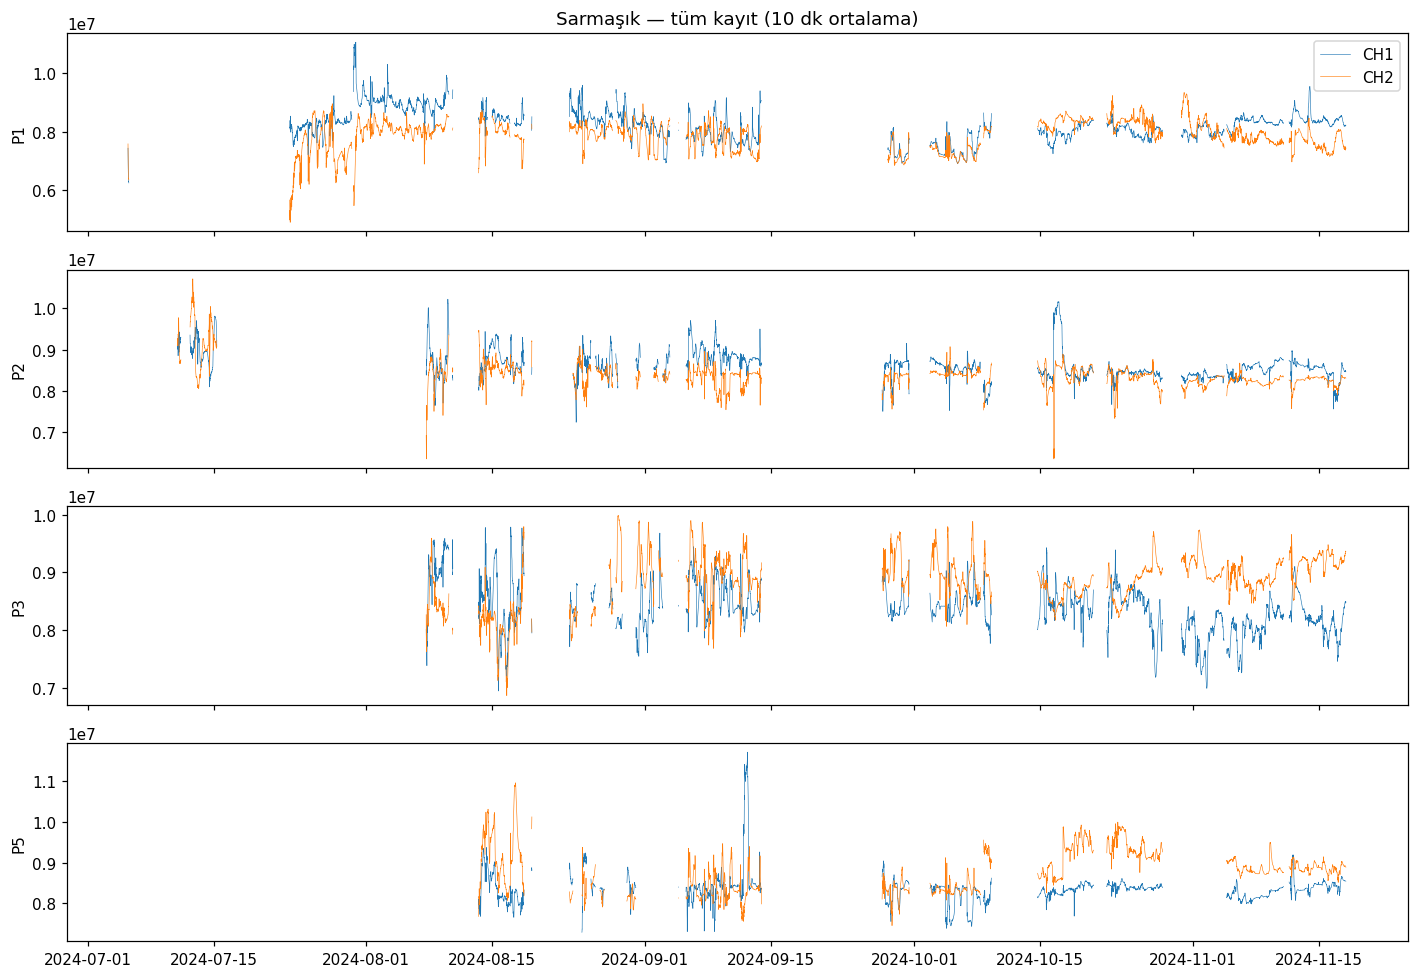

In [5]:
fig, ax = plt.subplots(len(bitkiler), 1, figsize=(13, 9), sharex=True)
for a, (b, d) in zip(ax, bitkiler.items()):
    s = d.resample('10min').mean()
    a.plot(s.index, s.CH1, lw=0.4, label='CH1')
    a.plot(s.index, s.CH2, lw=0.4, label='CH2')
    a.set_ylabel(b)
ax[0].legend(loc='upper right'); ax[0].set_title('Sarmaşık — tüm kayıt (10 dk ortalama)')
plt.tight_layout(); fig.savefig(SEKIL / 'sarmasik_tum_kayit.png'); plt.show()

## 3. Veri kapsaması: hangi günlerde ölçüm var?

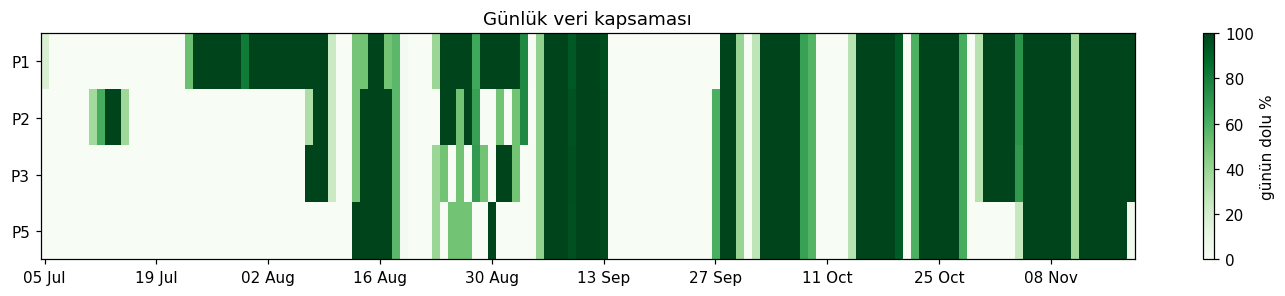

In [6]:
gunluk = pd.DataFrame({b: d.CH1.notna().resample('1D').mean() * 100 for b, d in bitkiler.items()})
fig, ax = plt.subplots(figsize=(13, 2.8))
im = ax.imshow(gunluk.T.fillna(0), aspect='auto', cmap='Greens', vmin=0, vmax=100)
ax.set_yticks(range(len(gunluk.columns)), gunluk.columns)
ticks = range(0, len(gunluk), 14)
ax.set_xticks(ticks, [gunluk.index[i].strftime('%d %b') for i in ticks])
plt.colorbar(im, label='günün dolu %'); ax.set_title('Günlük veri kapsaması')
plt.tight_layout(); fig.savefig(SEKIL / 'sarmasik_kapsama.png'); plt.show()

## 4. Hava durumu (10 dk aralık)

In [7]:
hava = sarmasik_hava()
hava.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ruzgar_hizi_ms,22032.0,0.66,0.41,0.0,0.4,0.5,0.80,3.9
ruzgar_yonu_derece,22032.0,221.58,119.05,0.0,113.0,268.0,327.00,359.0
sicaklik_c,22032.0,15.12,7.44,-3.3,9.9,14.7,19.92,35.6
bagil_nem_yuzde,22032.0,87.31,15.42,31.6,78.4,94.5,100.00,100.0
isinim_wm2,22032.0,201.66,346.63,0.0,0.0,5.0,234.00,1506.0
yagis_mm,22032.0,0.02,0.13,0.0,0.0,0.0,0.00,9.0
ciy_noktasi_c,22032.0,12.73,5.57,-3.8,9.0,13.4,17.50,24.5
buharlasma_mm,153.0,2.05,1.86,0.0,0.5,1.5,3.40,6.7


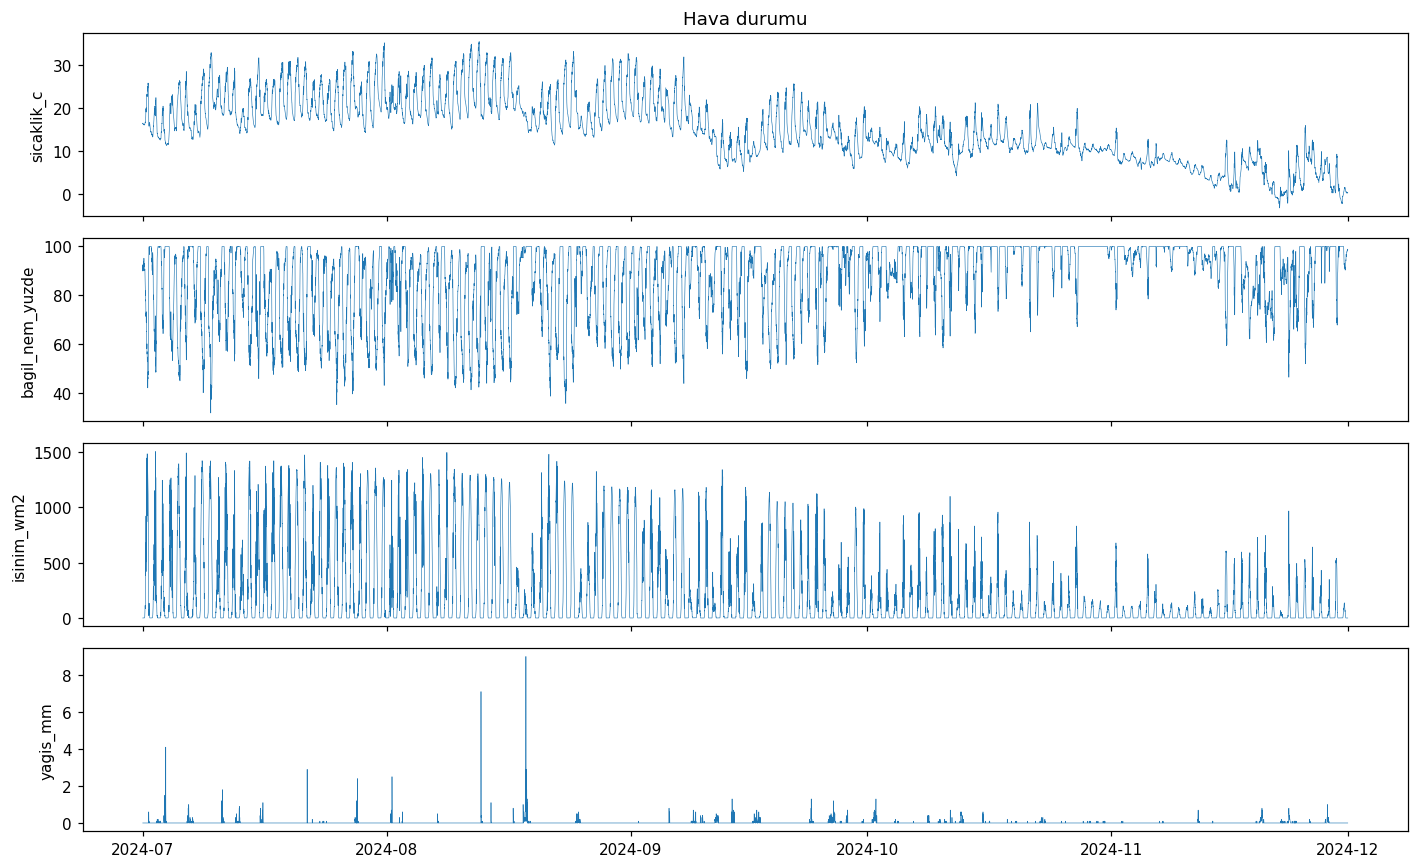

In [8]:
kanallar = ['sicaklik_c', 'bagil_nem_yuzde', 'isinim_wm2', 'yagis_mm']
fig, ax = plt.subplots(len(kanallar), 1, figsize=(13, 8), sharex=True)
for a, k in zip(ax, kanallar):
    a.plot(hava.index, hava[k], lw=0.4); a.set_ylabel(k)
ax[0].set_title('Hava durumu')
plt.tight_layout(); fig.savefig(SEKIL / 'sarmasik_hava.png'); plt.show()

## 5. Bir hafta yakından: bitki sinyali ve hava

`baslangic` tarihini değiştirerek farklı haftalara bakabilirsin.

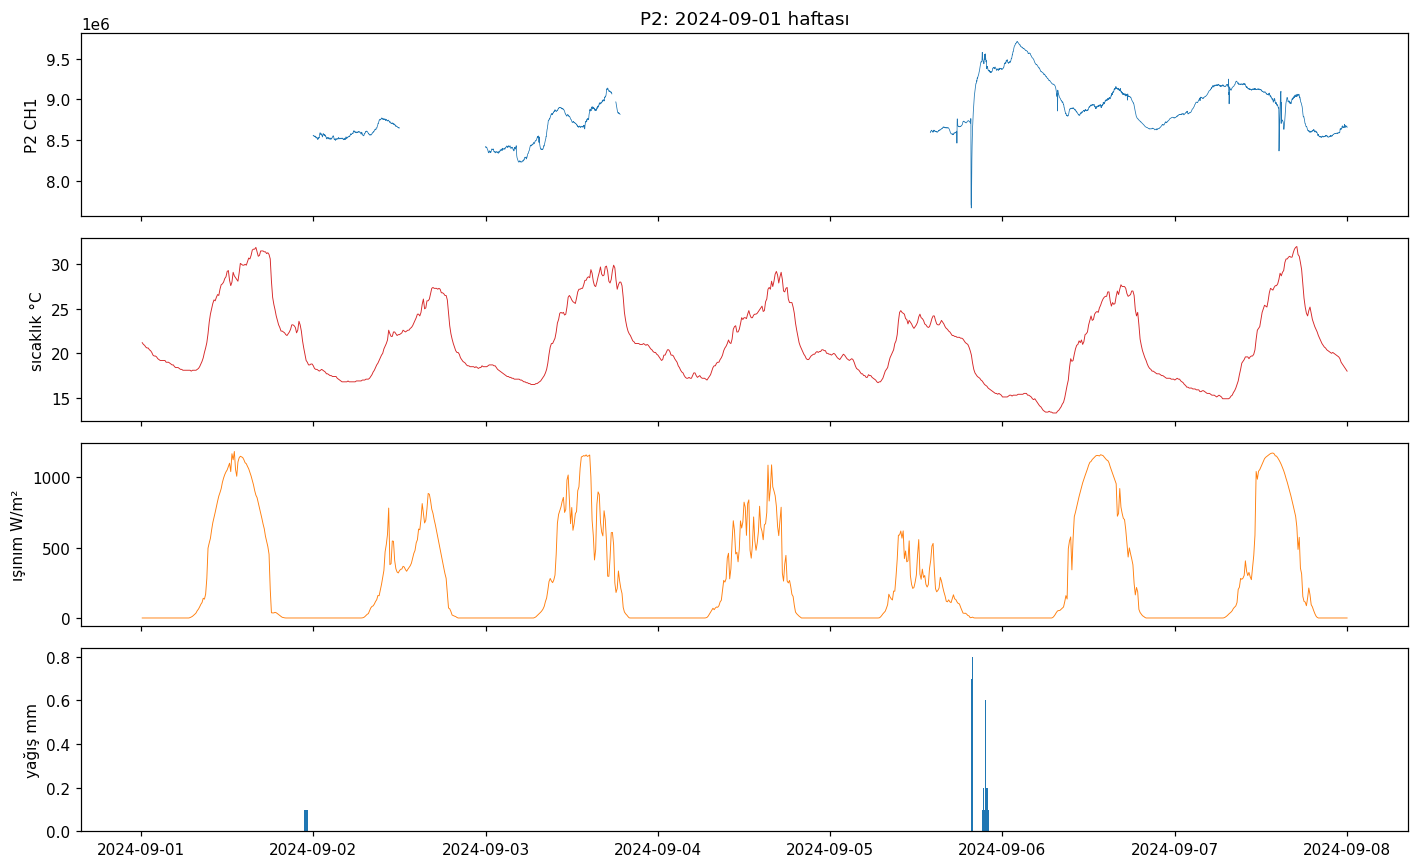

In [9]:
baslangic, bitki = '2024-09-01', 'P2'
bitis = pd.Timestamp(baslangic) + pd.Timedelta('7D')
d, h = bitkiler[bitki].loc[baslangic:bitis], hava.loc[baslangic:bitis]
fig, ax = plt.subplots(4, 1, figsize=(13, 8), sharex=True)
ax[0].plot(d.index, d.CH1, lw=0.5); ax[0].set_ylabel(f'{bitki} CH1')
ax[1].plot(h.index, h.sicaklik_c, lw=0.6, c='tab:red'); ax[1].set_ylabel('sıcaklık °C')
ax[2].plot(h.index, h.isinim_wm2, lw=0.6, c='tab:orange'); ax[2].set_ylabel('ışınım W/m²')
ax[3].bar(h.index, h.yagis_mm, width=0.007, color='tab:blue'); ax[3].set_ylabel('yağış mm')
ax[0].set_title(f'{bitki}: {baslangic} haftası')
plt.tight_layout(); fig.savefig(SEKIL / 'sarmasik_bir_hafta.png'); plt.show()